In [5]:
import os
import sys

import time
import itertools
import numpy as np
import torch
from matplotlib.pylab import plt
import gc

lib_decompre = "/var/home/dotamthuc/Works/Compress3DGS/Differentiable3DPC-Decompression-and-Rendering/"
sys.path.insert(0, lib_decompre)

from libs.dataloader.View import View, ViewCreator
from libs.dataloader.Scene import Scene
import decompress_render


lib_svraster = "/var/home/dotamthuc/Works/Compress3DGS/Baselines/svraster"
sys.path.insert(0, lib_svraster)
from src.sparse_voxel_model import SparseVoxelModel

np.set_printoptions(precision=3, suppress=True)

In [6]:
torch._C._cuda_init()

In [9]:
def load_geometry_from_sparse_voxels_model(sourse_path, load_attribute_field=True):
    voxel_model_frame = SparseVoxelModel(
        n_samp_per_vox=1,
        sh_degree=3,
        ss=1.5,
        white_background=False,
        black_background=False,
    )
    voxel_model_frame.load(sourse_path)

    geometry_info = {}
    #morton_code
    geometry_info["morton_code_tensor"] = voxel_model_frame.octpath.clone().detach()

    #vox_roots
    vox_roots = (voxel_model_frame.vox_center - 0.5 * voxel_model_frame.vox_size)
    geometry_info["vox_roots_tensor"] = vox_roots.clone().detach()
    geometry_info["vox_length_tensor"] = voxel_model_frame.vox_size.clone().detach()

    # Geometry conners
    geometry_info["vox2corners_tensor"] = voxel_model_frame.vox_key.clone().detach()
    geometry_info["vox_params_geo_tensor"] = voxel_model_frame._geo_grid_pts.clone().detach()

    # Colors
    if load_attribute_field:
        # SH0 = 0.28209479177387814
        # static_color  = (voxel_model_frame._sh0 * SH0 + 0.5).clone().detach()
        # static_color[static_color<0.0] = 0.0
        # geometry_info["vox_params_color_tensor"] = static_color
        geometry_info["vox_params_color_tensor"] = torch.concat([
            voxel_model_frame.sh0[:, None, :], voxel_model_frame.shs[:, :, :]
        ], dim=1)


    del voxel_model_frame
    torch.cuda.empty_cache()

    return geometry_info


def resize_rendering(render, size, mode='bilinear', align_corners=False):
    return torch.nn.functional.interpolate(
        render[None], size=size, mode=mode, align_corners=align_corners, antialias=True)[0]


class DensityField:
    def __init__(
        self,
        source_path,
        num_sample_per_voxel=1,
        load_attribute_field=True
    ):
        # CONFIG INFO
        self.num_sample_per_voxel = num_sample_per_voxel

        geometry_info = load_geometry_from_sparse_voxels_model(source_path, load_attribute_field)
        #### Define the Density Field
        self.voxel_morton_code = geometry_info["morton_code_tensor"]
        self.voxel_position    = geometry_info["vox_roots_tensor"]
        self.voxel_size        = geometry_info["vox_length_tensor"]
        self.voxel2corner      = geometry_info["vox2corners_tensor"]
        self.corner_geo_params = geometry_info["vox_params_geo_tensor"]
        self.num_voxels        = self.voxel_morton_code.shape[0]

        #### Define current Attribute Field
        if load_attribute_field:
            self.voxel_attribute_field = geometry_info["vox_params_color_tensor"]
        else:
            self.voxel_attribute_field = torch.full(
                [self.num_voxels, 3], 0.0, 
                dtype=torch.float32
            )
    
    def apply_phi(self, view_info):
        ss = 1.5
        w_src, h_src = view_info.render_width, view_info.render_height
        w, h = round(w_src * ss), round(h_src * ss)
        w_ss, h_ss = w / w_src, h / h_src

        camera_settings = decompress_render.renderer.CameraSettings(
            image_width=w,#view_info.render_width, 
            image_height=h,#view_info.render_height, 
            tanfovx=view_info.tanfovx, 
            tanfovy=view_info.tanfovy, 
            cx=view_info.cx * w_ss,
            cy=view_info.cy * h_ss,
            w2c_matrix=view_info.world2view.cuda(),
            c2w_matrix=view_info.view2world.cuda()
        )

        render_settings = decompress_render.renderer.RenderSettings(
            num_sample_per_vox=self.num_sample_per_voxel,
            bg_color=0.0,
            near=view_info.near,
            need_depth=False,
            track_max_w=False,
            debug=False,
        )

        out_color, out_depth, out_T, max_w = decompress_render.renderer.rasterize_voxels_main(
            camera_settings=camera_settings,
            render_settings=render_settings,
            morton_code=self.voxel_morton_code,
            vox_roots=self.voxel_position,
            vox_length=self.voxel_size,
            vox2corners=self.voxel2corner,
            vox_params_geo=self.corner_geo_params,
            vox_params_color=self.voxel_attribute_field,
        )
        out_color = out_color + out_T * out_color.mean((1,2), keepdim=True)
        # print(f"color.shape={out_color.shape}")
        out_color = resize_rendering(out_color, size=(h_src, w_src))

        rendered_image = torch.permute(out_color.clamp(0, 1), dims=(1, 2, 0)).detach()

        return rendered_image
    
    
    def apply_phi_with_F(self, voxel_attribute, view_info):

        ss = 1.5
        w_src, h_src = view_info.render_width, view_info.render_height
        w, h = round(w_src * ss), round(h_src * ss)
        w_ss, h_ss = w / w_src, h / h_src

        # if voxel_attribute.shape != (self.num_voxels, 3):
        #     raise Exception(f"Expect voxel_attribute in is static voxels color ({self.num_voxels}, 3) but got", voxel_attribute.shape)

        camera_settings = decompress_render.renderer.CameraSettings(
            image_width=w,#view_info.render_width, 
            image_height=h,#view_info.render_height, 
            tanfovx=view_info.tanfovx, 
            tanfovy=view_info.tanfovy, 
            cx=view_info.cx * w_ss,
            cy=view_info.cy * h_ss,
            w2c_matrix=view_info.world2view.cuda(),
            c2w_matrix=view_info.view2world.cuda()
        )

        render_settings = decompress_render.renderer.RenderSettings(
            num_sample_per_vox=self.num_sample_per_voxel,
            bg_color=0.0,
            near=view_info.near,
            need_depth=False,
            track_max_w=False,
            debug=False,
        )

        out_color, out_depth, out_T, max_w = decompress_render.renderer.rasterize_voxels_main(
            camera_settings=camera_settings,
            render_settings=render_settings,
            morton_code=self.voxel_morton_code,
            vox_roots=self.voxel_position,
            vox_length=self.voxel_size,
            vox2corners=self.voxel2corner,
            vox_params_geo=self.corner_geo_params,
            vox_params_color=voxel_attribute,
        )
        out_color = out_color + out_T * out_color.mean((1,2), keepdim=True)
        # print(f"color.shape={out_color.shape}")
        out_color = resize_rendering(out_color, size=(h_src, w_src))

        rendered_image = torch.permute(out_color.clamp(0, 1), dims=(1, 2, 0)).detach()


        return rendered_image


In [3]:
voxel_model_frame = SparseVoxelModel(
    n_samp_per_vox=1,
    sh_degree=3,
    ss=1.5,
    white_background=False,
    black_background=False,
)
voxel_model_frame.load("/var/home/dotamthuc/Works/Compress3DGS/Results/SVRaster/mip-nerf-360/bicycle/rate00/checkpoints/iter030000_model.pt")

In [5]:
scene_sourse = "/var/home/dotamthuc/Works/Compress3DGS/Data/mip-nerf-360/{}/".format("bicycle")
scene_dataset = Scene(
    scene_sourse, image_dir_name="images",
    res_downscale=0.0, res_width=1600,
    test_view_every=8
)
test_views = scene_dataset.get_test_views()

Read dataset in COLMAP format.
Done reading and creating views: 194 train views and 25 encoding views


In [9]:

def im_tensor2np(x):
    if x.shape[0] == 1:
        x = x.squeeze(0)
    if len(x.shape) == 3:
        x = x.moveaxis(0, -1)
    return x.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

checkpoint = "/var/home/dotamthuc/Works/Compress3DGS/Results/SVRaster/mip-nerf-360/bicycle/rate00/checkpoints/iter030000_model.pt"
denfield = DensityField(checkpoint)

In [6]:
list_psnr = []
for i, view in enumerate(test_views):
    output = denfield.apply_phi(view)
    rendered_img = output.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    img_true_target = im_tensor2np(view.rendered_true)
    mse_true = np.square(img_true_target/255 - rendered_img/255).mean()
    psnr = -10 * np.log10(mse_true)
    list_psnr.append(psnr)
    print(f"Test i={i}: psnr={psnr}")

Test i=0: psnr=21.623645148206244
Test i=1: psnr=20.038038243348318
Test i=2: psnr=20.15186731290877
Test i=3: psnr=21.417203334816527
Test i=4: psnr=22.24989221683918
Test i=5: psnr=23.665454860800693
Test i=6: psnr=25.79971754998285
Test i=7: psnr=25.511949985649736
Test i=8: psnr=24.91621767162769
Test i=9: psnr=25.563662556531128
Test i=10: psnr=24.642548834241925
Test i=11: psnr=23.996568022702668
Test i=12: psnr=26.24432865309347
Test i=13: psnr=27.333860113341384
Test i=14: psnr=27.018109523627135
Test i=15: psnr=27.129266549004637
Test i=16: psnr=25.731215339992104
Test i=17: psnr=26.709849114864554
Test i=18: psnr=28.392972096761202
Test i=19: psnr=27.845097728436315
Test i=20: psnr=27.0960697565743
Test i=21: psnr=27.49377417092669
Test i=22: psnr=28.515532646135085
Test i=23: psnr=24.586191643004213
Test i=24: psnr=26.87565551940566


In [10]:
list_psnr = []
for i, view in enumerate(test_views):
    output = denfield.apply_phi_with_F(denfield.voxel_attribute_field, view).detach()
    rendered_img = output.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    img_true_target = im_tensor2np(view.rendered_true)
    mse_true = np.square(img_true_target/255 - rendered_img/255).mean()
    psnr = -10 * np.log10(mse_true)
    list_psnr.append(psnr)
    print(f"Test i={i}: psnr={psnr}")

Test i=0: psnr=21.623645148206244
Test i=1: psnr=20.038038243348318
Test i=2: psnr=20.15186731290877
Test i=3: psnr=21.417203334816527
Test i=4: psnr=22.24989221683918
Test i=5: psnr=23.665454860800693
Test i=6: psnr=25.79971754998285
Test i=7: psnr=25.511949985649736
Test i=8: psnr=24.91621767162769
Test i=9: psnr=25.563662556531128
Test i=10: psnr=24.642548834241925
Test i=11: psnr=23.996568022702668
Test i=12: psnr=26.24432865309347
Test i=13: psnr=27.333860113341384
Test i=14: psnr=27.018109523627135
Test i=15: psnr=27.129266549004637
Test i=16: psnr=25.731215339992104
Test i=17: psnr=26.709849114864554
Test i=18: psnr=28.392972096761202
Test i=19: psnr=27.845097728436315
Test i=20: psnr=27.0960697565743
Test i=21: psnr=27.49377417092669
Test i=22: psnr=28.515532646135085
Test i=23: psnr=24.586191643004213
Test i=24: psnr=26.87565551940566


# RD curves

In [3]:


import sys
lib_decompre = "/home/dotamthuc-3090/Projects/ViewSynthesis/Differentiable3DPC-Decompression-and-Rendering"
sys.path.insert(0, lib_decompre)

from libs.rlgr_entropy_coder import rlgr
from libs.raht import raht, pointcloud3d


In [ ]:
scene_sourse = "/var/home/dotamthuc/Works/Compress3DGS/Data/mip-nerf-360/{}/".format("bicycle")
scene_dataset = Scene(
    scene_sourse, image_dir_name="images",
    res_downscale=0.0, res_width=1600,
    test_view_every=8
)
test_views = scene_dataset.get_test_views()

Read dataset in COLMAP format.


In [4]:

checkpoint = "/var/home/dotamthuc/Works/Compress3DGS/Results/SVRaster/mip-nerf-360/bicycle/rate00/checkpoints/iter030000_model.pt"
ref_denfield= DensityField(checkpoint)

####
voxel_morton_code = ref_denfield.voxel_morton_code.detach().cpu().numpy()
voxel_position = ref_denfield.voxel_position.detach().cpu().numpy()
voxel_size = ref_denfield.voxel_size.detach().cpu().numpy()
voxel2corner = ref_denfield.voxel2corner.detach().cpu().numpy()
corner_geo_params = ref_denfield.corner_geo_params.detach().cpu().numpy()
num_voxels = ref_denfield.num_voxels
voxel_attribute_field = ref_denfield.voxel_attribute_field.detach().cpu().numpy()

####
index = np.arange(0, voxel_morton_code.shape[0]).astype(np.int32)
order = np.argsort(voxel_morton_code[:, 0])

index = index[order]
voxel_morton_code_ordered = voxel_morton_code[order, 0]
voxel_size_ordered = voxel_size[order, 0]
voxel_attribute_field_ordered = voxel_attribute_field[order, :]


Transformed k=0
Transformed k=1
Transformed k=2
Transformed k=3
Transformed k=4
Transformed k=5
Transformed k=6
Transformed k=7
Transformed k=8
Transformed k=9
Transformed k=10
Transformed k=11
Transformed k=12
Transformed k=13
Transformed k=14
Transformed k=15
Inverse Transformed k=0
Inverse Transformed k=1
Inverse Transformed k=2
Inverse Transformed k=3
Inverse Transformed k=4
Inverse Transformed k=5
Inverse Transformed k=6
Inverse Transformed k=7
Inverse Transformed k=8
Inverse Transformed k=9
Inverse Transformed k=10
Inverse Transformed k=11
Inverse Transformed k=12
Inverse Transformed k=13
Inverse Transformed k=14
Inverse Transformed k=15
stepsize=0.0627, bpv=104.3798, psnr=40.0 


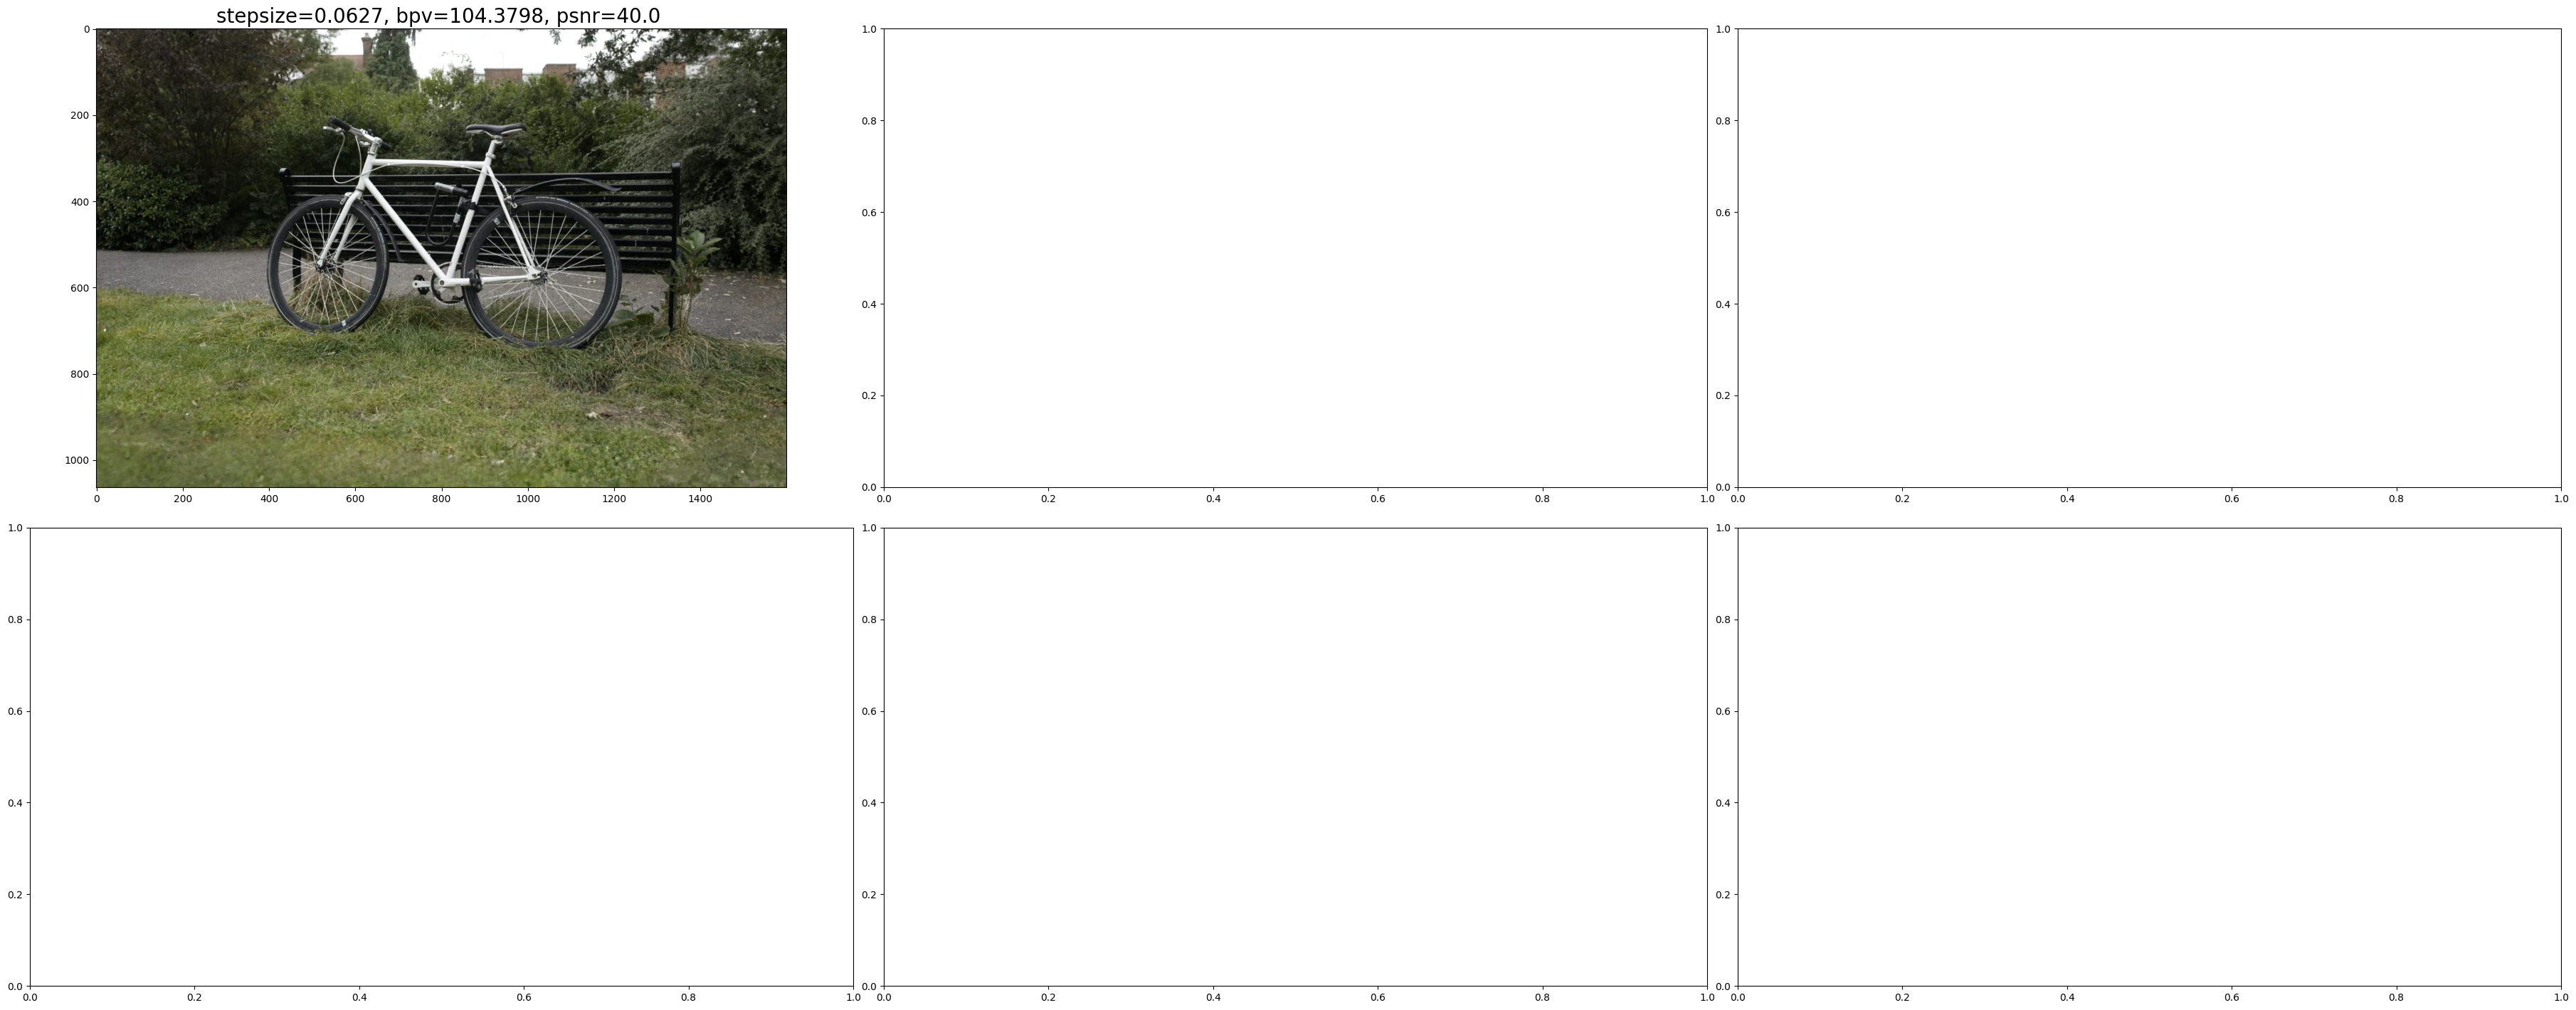

list_bpv=[104.37981973   0.           0.           0.           0.        ]
list_psnr=[40.  0.  0.  0.  0.]


NameError: name 'transformed_attributes' is not defined

In [7]:

def bit_rate_huffman(coefs_index):
    bins, count = np.unique(coefs_index, return_counts=True)

    bin_index = interleave_int(bins)
    bin_cost = -np.log2(count / np.sum(count))

    cost_map = np.zeros(np.max(bin_index)+1)+10e32
    for (i, bits) in zip(bin_index, bin_cost):
        cost_map[i]=bits

    cost = cost_map[interleave_int(coefs_index)]
    return cost.sum()

def interleave_int(index):
    map = 2 * index
    neg = (index < 0)
    map_neg = -map[neg]
    map[neg] = map_neg - 1

    return map


stepsizes = np.array([16, 32, 60, 128, 256]) / 255
fig, ax = plt.subplots(ncols=3, nrows=2, figsize=(12 * 3, 7*2))
dist = np.zeros(len(stepsizes))
psnr = np.zeros(len(stepsizes))
rate = np.zeros(len(stepsizes))
# for i, stepsize in enumerate(stepsizes):

# Transform.
binlevel, coeff_binlevel = raht.RahtPrologue(voxel_morton_code_ordered)

transformed_attributes = np.zeros_like(voxel_attribute_field_ordered)
for k in range(16): 
    print(f"Transformed k={k}")
    transformed_attributes[:, k] = raht.Raht(binlevel, voxel_attribute_field_ordered[:, k])


for i, stepsize in enumerate(stepsizes):
    # Quantize transformed attributes to indices.
    quantization_indices = np.round(
        transformed_attributes / stepsize).astype(np.int32)

    # Entropy encode/decode.  (Here just copy.)
    # decoded_morton_code = voxel_morton_code_ordered
    # decoded_voxel_size_ordered = voxel_size_ordered
    # decoded_quantization_indices = quantization_indices

    # De-quantize.
    decoded_transformed_attributes = quantization_indices * stepsize

    # Inverse transform.
    # binlevel, coeff_binlevel = raht.RahtPrologue(decoded_morton_code)

    decoded_attributes_ordered = np.zeros_like(decoded_transformed_attributes)
    for k in range(16): 
        print(f"Inverse Transformed k={k}")
        decoded_attributes_ordered[:, k] = raht.InvRaht(binlevel, decoded_transformed_attributes[:, k])

    # Reverse ordering
    decoded_attributes = np.zeros_like(decoded_attributes_ordered)
    decoded_attributes[index] = decoded_attributes_ordered
    
    order_coefs = np.argsort(coeff_binlevel, kind="mergesort")
    quantization_indices_ordered = quantization_indices[order_coefs]

    del transformed_attributes
    del quantization_indices
    del decoded_transformed_attributes
    del decoded_attributes_ordered
    gc.collect()

    for k in range(16): 
        rate[i] += bit_rate_huffman(quantization_indices_ordered[:, k, 0])
        rate[i] += bit_rate_huffman(quantization_indices_ordered[:, k, 1])
        rate[i] += bit_rate_huffman(quantization_indices_ordered[:, k, 2])

    del quantization_indices_ordered
    gc.collect()

    # Distotion
    decoded_attributes_tensor = torch.tensor(decoded_attributes, device="cuda", dtype=torch.float)
    list_mse = []
    pick_view_i = 0
    with torch.no_grad():
        for view_i, view in enumerate(test_views):
            tensor_img = ref_denfield.apply_phi_with_F(decoded_attributes_tensor, view).detach()
            rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

            tensor_img_target = ref_denfield.apply_phi(view).detach()
            img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

            mse = np.square(img_target/255 - rendered_img/255).mean()
            list_mse.append(mse)

            if view_i == pick_view_i:
                rendered_img_picked = rendered_img


    dist[i] = np.round(np.mean(list_mse), 4)
    psnr[i] = np.round(-10 * np.log10(dist[i]), 4)
    ax[i//3][i%3].imshow(rendered_img_picked)
    ax[i//3][i%3].set_title(f'stepsize={np.round(stepsize, 4)}, bpv={np.round(rate[i]/num_voxels, 4)}, psnr={psnr[i]} ', fontsize=20)

    # Print details.
    print(f'stepsize={np.round(stepsize, 4)}, bpv={np.round(rate[i]/num_voxels, 4)}, psnr={psnr[i]} ')

    fig.tight_layout(h_pad=2, w_pad=0, pad=0)
    plt.show()
    print(f"list_bpv={np.array(rate)/ref_denfield.num_voxels}")
    print(f"list_psnr={np.array(psnr)}")


In [ ]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(16, 7))


## BASELINE 
# stepsize=0.0627, bpv=104.3798, psnr=40.0 

# bit_per_voxel = np.array([6.2813, 3.4782, 1.4239, 0.463 , 0.1034, 0.0297])
# rendered_rgb_psnr = np.array([35.2288, 30.9691, 26.7778, 23.9794, 21.6749, 20.1323])
# ax.plot(bit_per_voxel, rendered_rgb_psnr, '-o', label="Baseline RAHT")



############ 
# plt.yticks(ticks=np.arange(20, 48, step=0.5), labels=["{:.1f}".format(x) if i%2==0 else "" for i, x in enumerate(np.arange(20, 48, step=0.5))], fontsize=32)
plt.xticks(ticks=np.arange(0, 7, step=0.5), labels=["{:.1f}".format(x) if i%2==0 else "" for i, x in enumerate(np.arange(0, 7, step=0.5))], rotation=45, fontsize=32)
plt.grid()
plt.legend(fancybox=True, framealpha=0.5, prop={'size': 20})
plt.xlabel('Bit per voxel', fontsize=32)
# plt.xlim((0.3, 2.8))
# plt.ylim((36, 46.0))
plt.ylabel('Rendered RBG PSNR (dB)', fontsize=32)
plt.title('Bicycle Scene', fontsize=32)

In [37]:
np.mean(list_psnr)

25.2219475437129

# Energy Compaction

In [7]:
scene_sourse = "/var/home/dotamthuc/Works/Compress3DGS/Data/mip-nerf-360/{}/".format("bicycle")
scene_dataset = Scene(
    scene_sourse, image_dir_name="images",
    res_downscale=0.0, res_width=1600,
    test_view_every=8
)
test_views = scene_dataset.get_test_views()

Read dataset in COLMAP format.
Done reading and creating views: 194 train views and 25 encoding views


In [10]:

checkpoint = "/var/home/dotamthuc/Works/Compress3DGS/Results/SVRaster/mip-nerf-360/bicycle/rate00/checkpoints/iter030000_model.pt"
ref_denfield= DensityField(checkpoint)

####
voxel_morton_code = ref_denfield.voxel_morton_code.detach().cpu().numpy()
voxel_position = ref_denfield.voxel_position.detach().cpu().numpy()
voxel_size = ref_denfield.voxel_size.detach().cpu().numpy()
voxel2corner = ref_denfield.voxel2corner.detach().cpu().numpy()
corner_geo_params = ref_denfield.corner_geo_params.detach().cpu().numpy()
num_voxels = ref_denfield.num_voxels
voxel_attribute_field = ref_denfield.voxel_attribute_field.detach().cpu().numpy()

####
index = np.arange(0, voxel_morton_code.shape[0]).astype(np.int32)
order = np.argsort(voxel_morton_code[:, 0])

index = index[order]
voxel_morton_code_ordered = voxel_morton_code[order, 0]
voxel_size_ordered = voxel_size[order, 0]
voxel_attribute_field_ordered = voxel_attribute_field[order, :]


In [ ]:
dist = []
psnr = []
for ncoefs in range(1, 17):
    truncated_coefs = np.zeros_like(voxel_attribute_field_ordered)
    truncated_coefs[index, :ncoefs] = voxel_attribute_field_ordered[:, :ncoefs]

    list_mse = []
    pick_view_i = 0
    with torch.no_grad():

        truncated_coefs_tensor = torch.tensor(truncated_coefs, device="cuda", dtype=torch.float)
        for view_i, view in enumerate(test_views):
            tensor_img = ref_denfield.apply_phi_with_F(truncated_coefs_tensor, view).detach()
            rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

            tensor_img_target = ref_denfield.apply_phi(view).detach()
            img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

            mse = np.square(img_target/255 - rendered_img/255).mean()
            list_mse.append(mse)

            if view_i == pick_view_i:
                rendered_img_picked = rendered_img


    # Print details.
    dist.append(np.mean(list_mse))
    psnr.append(np.round(-10 * np.log10(np.mean(list_mse)), 4))

    print(f'ncoefs={ncoefs}, psnr={psnr[-1]}')

print(f"psnr={psnr}")

ncoefs=1, psnr=23.9083
ncoefs=2, psnr=24.5693
ncoefs=3, psnr=25.1598
ncoefs=4, psnr=25.8635
ncoefs=5, psnr=26.1601
ncoefs=6, psnr=26.4003
ncoefs=7, psnr=26.9967
ncoefs=8, psnr=27.8473
ncoefs=9, psnr=28.5388
ncoefs=10, psnr=29.3123
ncoefs=11, psnr=29.8021
ncoefs=12, psnr=30.3615
ncoefs=13, psnr=31.7934
ncoefs=14, psnr=34.3099
ncoefs=15, psnr=38.0124
ncoefs=16, psnr=inf
psnr=[23.9083, 24.5693, 25.1598, 25.8635, 26.1601, 26.4003, 26.9967, 27.8473, 28.5388, 29.3123, 29.8021, 30.3615, 31.7934, 34.3099, 38.0124, inf]


/tmp/ipykernel_26906/4242121609.py:28: RuntimeWarning: divide by zero encountered in log10
  psnr.append(np.round(-10 * np.log10(np.mean(list_mse)), 4))


In [14]:
X = voxel_attribute_field_ordered.reshape(-1, 48)
# C = np.cov(X, rowvar=False)
# S, U = np.linalg.eig(C)
U, S, V = np.linalg.svd(X.T, full_matrices=False)

In [31]:
U[:, 0]

array([-0.495, -0.407, -0.767,  0.002,  0.004,  0.003,  0.003,  0.002,
        0.002,  0.003,  0.003,  0.007,  0.004,  0.003,  0.005, -0.005,
       -0.004, -0.005,  0.001,  0.001,  0.002, -0.001, -0.001, -0.002,
       -0.009, -0.007, -0.013,  0.003,  0.004,  0.002, -0.001, -0.   ,
       -0.001,  0.001,  0.001,  0.001, -0.003, -0.003, -0.004,  0.001,
        0.001,  0.002,  0.001,  0.   ,  0.001,  0.004,  0.004,  0.007],
      dtype=float32)

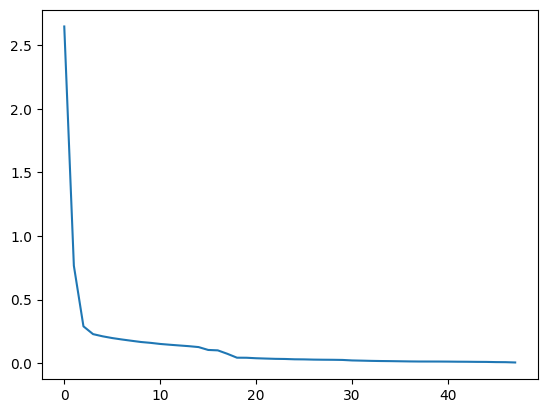

In [28]:
plt.plot(np.std(X_transformed.reshape(-1, 48), axis=0))
plt.show()

In [17]:
# X = voxel_attribute_field_ordered.reshape(-1, 48)
# # C = np.cov(X, rowvar=False)
# # S, U = np.linalg.eig(C)
# U, S, V = np.linalg.svd(X.T)
X_transformed = (X @ U).reshape(-1, 16, 3)

dist = []
psnr = []
for ncoefs in range(1, 16):
    truncated_coefs = np.zeros_like(X_transformed)
    truncated_coefs[index, :ncoefs] = X_transformed[:, :ncoefs]

    recon_coefs = (truncated_coefs.reshape(-1, 48) @ U.T).reshape(-1, 16, 3)

    list_mse = []
    pick_view_i = 0
    with torch.no_grad():

        recon_coefs_tensor = torch.tensor(recon_coefs, device="cuda", dtype=torch.float)
        for view_i, view in enumerate(test_views):
            tensor_img = ref_denfield.apply_phi_with_F(recon_coefs_tensor, view).detach()
            rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

            tensor_img_target = ref_denfield.apply_phi(view).detach()
            img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

            mse = np.square(img_target/255 - rendered_img/255).mean()
            list_mse.append(mse)

            if view_i == pick_view_i:
                rendered_img_picked = rendered_img


    # Print details.
    dist.append(np.mean(list_mse))
    psnr.append(np.round(-10 * np.log10(np.mean(list_mse)), 4))

    print(f'ncoefs={ncoefs}, psnr={psnr[-1]}')


print(f"psnr={psnr}")



ncoefs=1, psnr=24.0873
ncoefs=2, psnr=25.4551
ncoefs=3, psnr=27.1102
ncoefs=4, psnr=29.721
ncoefs=5, psnr=36.0953
ncoefs=6, psnr=37.4836
ncoefs=7, psnr=38.7328
ncoefs=8, psnr=40.5503
ncoefs=9, psnr=41.9651
ncoefs=10, psnr=46.0744
ncoefs=11, psnr=46.8254
ncoefs=12, psnr=47.2967
ncoefs=13, psnr=48.6818
ncoefs=14, psnr=50.8124
ncoefs=15, psnr=58.0856
psnr=[24.0873, 25.4551, 27.1102, 29.721, 36.0953, 37.4836, 38.7328, 40.5503, 41.9651, 46.0744, 46.8254, 47.2967, 48.6818, 50.8124, 58.0856]


Text(0.5, 1.0, 'Bicycle Scene')

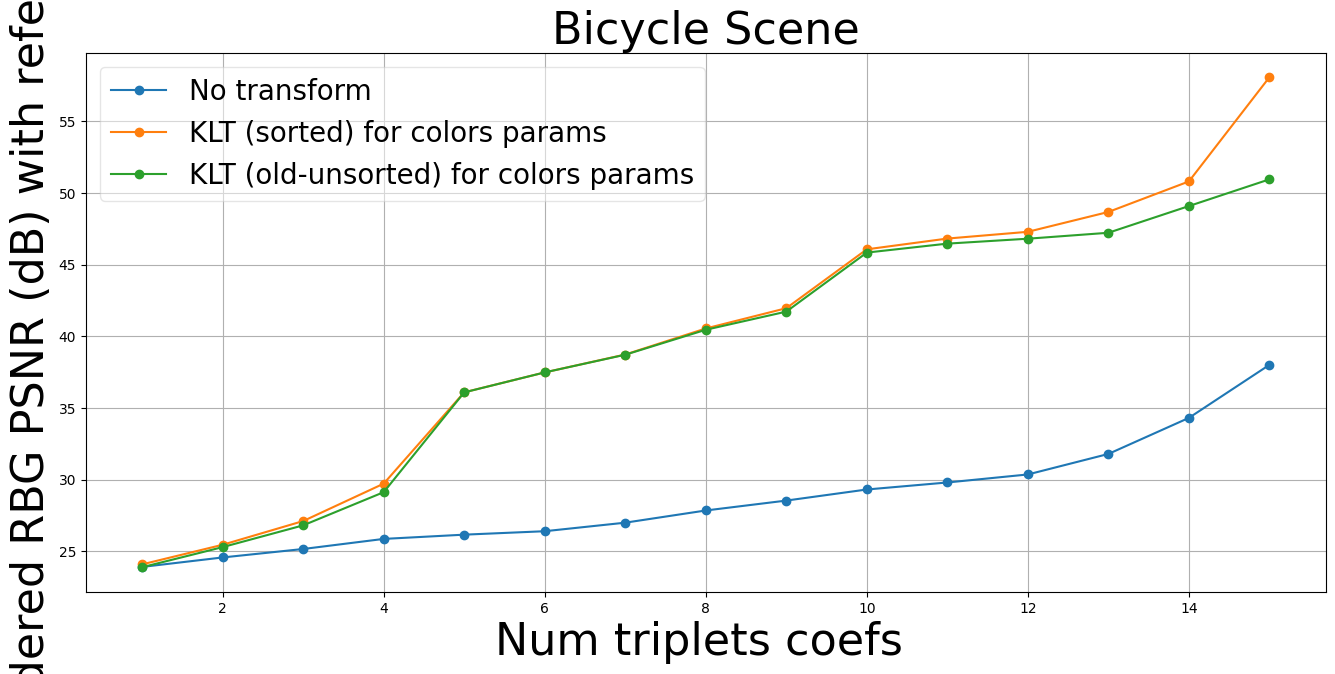

In [22]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(16, 7))


## BASELINE 
psnr=[23.9083, 24.5693, 25.1598, 25.8635, 26.1601, 26.4003, 26.9967, 27.8473, 28.5388, 29.3123, 29.8021, 30.3615, 31.7934, 34.3099, 38.0124]
ax.plot(np.arange(1, 16), psnr, '-o', label="No transform")

psnr=[24.0873, 25.4551, 27.1102, 29.721, 36.0953, 37.4836, 38.7328, 40.5503, 41.9651, 46.0744, 46.8254, 47.2967, 48.6818, 50.8124, 58.0856]
ax.plot(np.arange(1, 16), psnr, '-o', label="KLT (sorted) for colors params")

psnr=[23.8876, 25.2914, 26.8098, 29.1258, 36.0901, 37.4846, 38.7185, 40.4601, 41.7265, 45.8464, 46.4718, 46.8156, 47.2296, 49.0935, 50.9584]
ax.plot(np.arange(1, 16), psnr, '-o', label="KLT (old-unsorted) for colors params")

############ 
# plt.yticks(ticks=np.arange(20, 48, step=0.5), labels=["{:.1f}".format(x) if i%2==0 else "" for i, x in enumerate(np.arange(20, 48, step=0.5))], fontsize=32)
# plt.xticks(ticks=np.arange(0, 7, step=0.5), labels=["{:.1f}".format(x) if i%2==0 else "" for i, x in enumerate(np.arange(0, 7, step=0.5))], rotation=45, fontsize=32)
plt.grid()
plt.legend(fancybox=True, framealpha=0.5, prop={'size': 20})
plt.xlabel('Num triplets coefs ', fontsize=32)
# plt.xlim((0.3, 2.8))
# plt.ylim((36, 46.0))
plt.ylabel('Rendered RBG PSNR (dB) with reference', fontsize=32)
plt.title('Bicycle Scene', fontsize=32)

# Extract Color matrix

In [11]:

SH_C0 = 0.28209479177387814
SH_C1 = 0.4886025119029199
SH_C2 = [
    1.0925484305920792,
    -1.0925484305920792,
    0.31539156525252005,
    -1.0925484305920792,
    0.5462742152960396
]
SH_C3 = [
    -0.5900435899266435,
    2.890611442640554,
    -0.4570457994644658,
    0.3731763325901154,
    -0.4570457994644658,
    1.445305721320277,
    -0.5900435899266435
]
def computeColorFromSH(
        dir, coefs_mask,
    ):

    dir_norm = np.sqrt(np.sum((dir**2)))
    # print(f"dir={dir} dir_norm={dir_norm}")
    dir = dir / dir_norm

    # // The implementation is loosely based on code for
    # // "Differentiable Point-Based Radiance Fields for
    # // Efficient View Synthesis" by Zhang et al. (2022)
    sh = coefs_mask[1:, :]
    sh0 = coefs_mask[0, :]

    # DEG 0
    result = SH_C0 * sh0

    #DEG 1
    x,y,z = dir[0], dir[1], dir[2]
    result = result - SH_C1 * y * sh[0] + SH_C1 * z * sh[1] - SH_C1 * x * sh[2]

    #DEG 2
    xx = x * x
    yy = y * y
    zz = z * z
    xy = x * y
    yz = y * z
    xz = x * z
    result = result + \
        SH_C2[0] * xy * sh[3] + \
        SH_C2[1] * yz * sh[4] + \
        SH_C2[2] * (2.0 * zz - xx - yy) * sh[5] + \
        SH_C2[3] * xz * sh[6] + \
        SH_C2[4] * (xx - yy) * sh[7]
    
    # DEG 3
    result = result + \
        SH_C3[0] * y * (3.0 * xx - yy) * sh[8] + \
        SH_C3[1] * xy * z * sh[9] + \
        SH_C3[2] * y * (4.0 * zz - xx - yy) * sh[10] + \
        SH_C3[3] * z * (2.0 * zz - 3.0 * xx - 3.0 * yy) * sh[11] + \
        SH_C3[4] * x * (4.0 * zz - xx - yy) * sh[12] + \
        SH_C3[5] * z * (xx - yy) * sh[13] + \
        SH_C3[6] * x * (xx - 3.0 * yy) * sh[14] 

    result = result
    # result[result<=0] = 0.0
    return result


In [12]:
list_dir = [
    (-1, -1, -1), (-1, -1, 0), (-1, -1, 1), 
    (-1, 0, -1), (-1, 0, 0), (-1, 0, 1), 
    (-1, 1, -1), (-1, 1, 0), (-1, 1, 1),
    (0, -1, -1), (0, -1, 0), (0, -1, 1), 
    (0, 0, -1), (0, 0, 1), 
    (0, 1, -1), (0, 1, 0), (0, 1, 1), 
    (1, -1, -1), (1, -1, 0), (1, -1, 1), 
    (1, 0, -1), (1, 0, 0), (1, 0, 1), 
    (1, 1, -1), (1, 1, 0), (1, 1, 1)
]
transformM = []
for dir in list_dir:
    out_dir = []
    for c_i in range(16):
        out_c_i = []
        for k in range(3):
            coefs = np.zeros((16, 3))
            coefs[c_i, k] = 1.0
            out_c_i.append(computeColorFromSH(np.array(dir), coefs))
        out_dir.append(out_c_i)
    transformM.append(out_dir)
    
transformM = np.array(transformM)
print(f"transformM.shape={transformM.shape}")
transformM = np.transpose(transformM, (0, 3, 1, 2)).reshape(26*3, 48)
print(f"transformM.shape={transformM.shape}")

transformM.shape=(26, 16, 3, 3)
transformM.shape=(78, 48)


In [8]:

# transformM = []
# for dir in range(1000):
#     out_dir = []
#     for c_i in range(16):
#         out_c_i = []
#         for k in range(3):
#             coefs = np.zeros((16, 3))
#             coefs[c_i, k] = 1.0
#             out_c_i.append(computeColorFromSH(np.random.uniform(0, 1, size=(3)), coefs))
#         out_dir.append(out_c_i)
#     transformM.append(out_dir)


# transformM = np.array(transformM)
# transformM = np.transpose(transformM, (0, 3, 1, 2)).reshape(1000*3, 48)

In [13]:
M = transformM
MtM = (M.T @ M)
U, S, Vt = np.linalg.svd(MtM)
MtT_sqrt_inv = U.T @ np.diag(1/np.sqrt(S)) @ U

In [14]:
# M = transformM
# MtM = (M.T @ M)
# S, U = np.linalg.eig(MtM)
# order = np.argsort(-S)

# coef_index = np.arange(0, 48).astype(np.int32)
# coef_index = coef_index[order]

# MtM = MtM[order, :][:, order]
# MtT_sqrt_inv = U.T @ np.diag(1/np.sqrt(S)) @ U
# MtT_sqrt_inv = MtT_sqrt_inv[order, :][:, order]
# plt.matshow(MtM)
# plt.show()

In [15]:
# X = voxel_attribute_field_ordered.reshape(-1, 48)
X_transformed = (voxel_attribute_field_ordered.reshape(-1, 48) @ MtM @ MtT_sqrt_inv).reshape(-1, 16, 3)

In [17]:
# X = voxel_attribute_field_ordered.reshape(-1, 48)
# X_transformed = (X @ MtM @ MtT_sqrt_inv).reshape(-1, 16, 3)

dist = []
psnr = []
for ncoefs in range(1, 16):
    # truncated_coefs = np.zeros_like(X_transformed)
    # truncated_coefs[:, :ncoefs] = X_transformed[:, :ncoefs]
    recon_coefs = (X_transformed[:, :(ncoefs*3)] @ MtT_sqrt_inv[:(ncoefs*3)]).reshape(-1, 16, 3)

    list_mse = []
    pick_view_i = 0
    with torch.no_grad():
        recon_coefs_tensor = torch.from_numpy(recon_coefs).cuda()
        for view_i, view in enumerate(test_views):
            tensor_img = ref_denfield.apply_phi_with_F(recon_coefs_tensor, view).detach()
            rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

            tensor_img_target = ref_denfield.apply_phi(view).detach()
            img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

            mse = np.square(img_target/255 - rendered_img/255).mean()
            list_mse.append(mse)

            if view_i == pick_view_i:
                rendered_img_picked = rendered_img
        
        torch.cuda.empty_cache()


    # Print details.
    dist.append(np.mean(list_mse))
    psnr.append(np.round(-10 * np.log10(np.mean(list_mse)), 4))

    print(f'ncoefs={ncoefs}, psnr={psnr[-1]}')
print(f"psnr={psnr}")

psnr=[]


In [21]:
with torch.no_grad():
    for view_i, view in enumerate(test_views):
        tensor_img = ref_denfield.apply_phi_with_F(recon_coefs_tensor, view).detach()
        rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

        tensor_img_target = ref_denfield.apply_phi(view).detach()
        img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

        mse = np.square(img_target/255 - rendered_img/255).mean()
        list_mse.append(mse)

        if view_i == pick_view_i:
            rendered_img_picked = rendered_img

OutOfMemoryError: CUDA out of memory. Tried to allocate 9.23 GiB. GPU 0 has a total capacity of 23.55 GiB of which 7.65 GiB is free. Process 6880 has 46.66 MiB memory in use. Process 7628 has 9.54 MiB memory in use. Process 9191 has 27.04 MiB memory in use. Including non-PyTorch memory, this process has 15.42 GiB memory in use. Of the allocated memory 14.67 GiB is allocated by PyTorch, and 469.80 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
recon_coefs.shape

(1, 48)

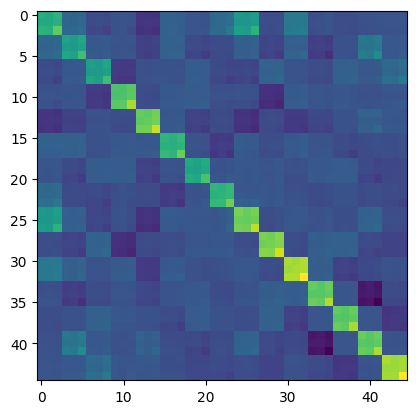

In [24]:
X = voxel_attribute_field_ordered.reshape(-1, 48)
C = np.cov(X, rowvar=False)
plt.imshow(C[3:, 3:])

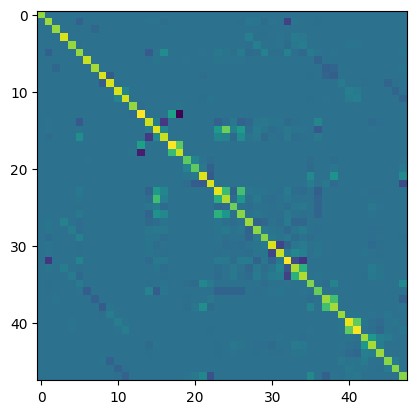

In [29]:
plt.imshow(MtM @ MtT_sqrt_inv @ MtT_sqrt_inv)

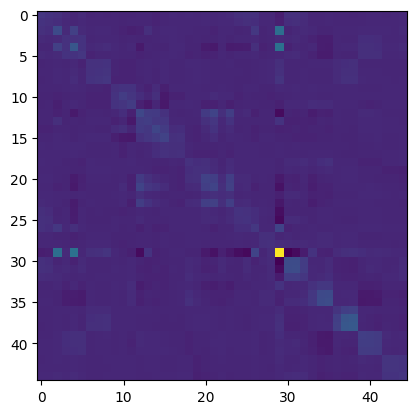

In [28]:
X = voxel_attribute_field_ordered.reshape(-1, 48) @ MtM @ MtT_sqrt_inv @ MtT_sqrt_inv
C = np.cov(X, rowvar=False)
plt.imshow(C[3:, 3:])

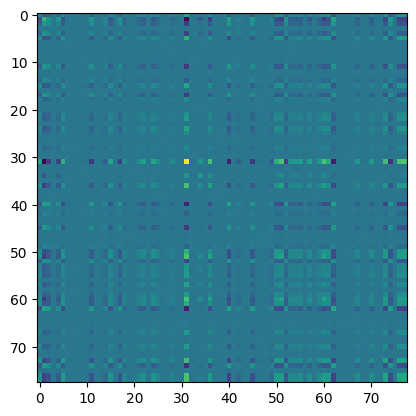

In [23]:
X = voxel_attribute_field_ordered.reshape((-1, 48)) @ transformM.reshape(48, 26*3) + 0.5
C = np.cov(X, rowvar=False)
plt.imshow(C)

In [30]:
X.reshape(-1, 26, 3)[1, ]

array([[ 0.866,  0.004, -0.129],
       [ 0.501,  0.325,  1.114],
       [ 0.582,  0.557,  0.511],
       [ 0.384,  0.514,  0.036],
       [ 0.393,  0.556,  0.275],
       [ 0.996,  0.523,  0.006],
       [ 0.668,  0.415,  0.583],
       [ 0.668,  1.02 ,  0.569],
       [ 0.896,  0.575,  0.449],
       [ 0.463,  0.83 ,  0.463],
       [ 0.49 ,  1.495,  0.477],
       [ 0.465,  0.295,  0.51 ],
       [ 0.943,  0.548,  0.43 ],
       [ 0.562, -0.299,  0.468],
       [ 0.326,  0.545,  0.627],
       [ 0.063,  0.496,  0.499],
       [ 0.526,  0.259,  1.12 ],
       [ 0.933,  0.072,  0.72 ],
       [ 0.749,  0.756,  0.624],
       [ 0.754,  0.465,  0.737],
       [ 0.898,  1.114, -0.113],
       [ 0.525,  0.411,  0.328],
       [ 0.494,  0.876,  0.486],
       [ 0.511,  0.92 ,  0.463],
       [ 0.522,  1.23 ,  0.093],
       [ 0.49 ,  1.339,  1.162]])

In [32]:
C[:3, :3]

array([[ 0.178, -0.253, -0.17 ],
       [-0.253,  0.533,  0.258],
       [-0.17 ,  0.258,  0.199]])